In [121]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
from src import corpus,keymap,optimization

from tqdm import tqdm

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [122]:
char_freqs,bigram_matrix,chars=corpus.get_matrix_from_json("ressources/fre_en.json")
ergo_chords=keymap.generate_ergonomic_chords()

POP_SIZE =350  # Population size for genetic algorithm
GENS = 70  # Number of generations
MUTATION_RATE = 0.5  # Probability of mutation
layout_cost=lambda layout: optimization.layout_cost(layout,char_freqs,bigram_matrix,ergo_chords)



1.6433491854314768: 100%|██████████| 70/70 [01:02<00:00,  1.12it/s]


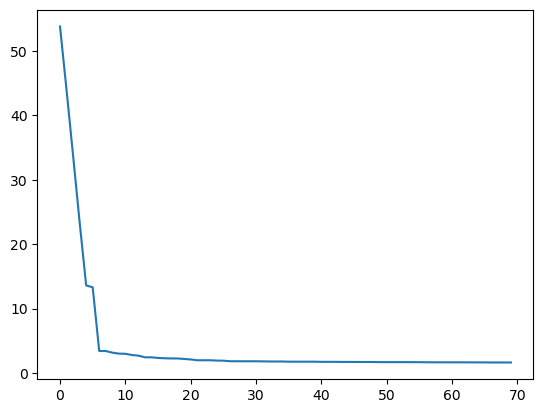

In [123]:
import random
best_score = []
population = [keymap.generate_random_layout(len(ergo_chords)) for _ in range(POP_SIZE)]

progress=tqdm(range(GENS))
for _ in progress:
    population = sorted(population, key=layout_cost) 
    progress.set_description(str(layout_cost(population[0])))
    
        # Rank by cost
    best_score.append(layout_cost(population[0]))
    next_gen = population[:POP_SIZE // 2]  # Keep best 50%
    
    while len(next_gen) < POP_SIZE:
        p1, p2 = random.sample(population[:POP_SIZE // 4], 2)  # Select top candidates
        child = keymap.crossover(p1, p2)
        child = keymap.mutate(child,MUTATION_RATE)
        next_gen.append(child)
    
    population = next_gen  # Move to next generation

best_layout=sorted(population, key=layout_cost)[0]  # Best layout
plt.plot(best_score)

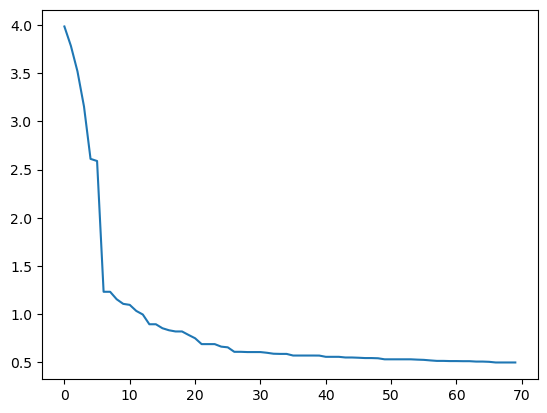

In [124]:
plt.plot(np.log(best_score))

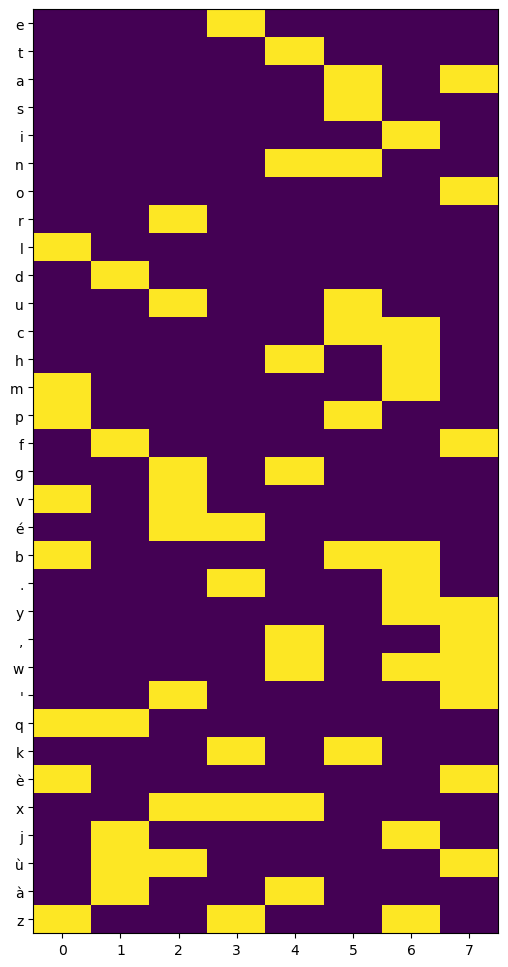

In [125]:
keymap.plot_layout(best_layout,ergo_chords,chars)

In [126]:
c=keymap.get_chords(best_layout,ergo_chords,char_freqs)

In [127]:
index=[0,0,0,1]*2
majeur=[0,0,1,0]*2
annulaire=[0,1,0,0]*2
auriculaire=[1,0,0,0,]*2
list_same_finger = np.vstack([index,majeur,annulaire,auriculaire])

In [128]:
i=0
j=1
i1=c[i]
i2=c[:]
sum((i1^i2)@list_same_finger.T>=2)*1

array([9, 0, 0, 0])

In [129]:
i1=np.array(index)
i2=np.array(index)
i1[-1]=0
i2[3]=0
i1=np.expand_dims(i1,0)
i2=np.expand_dims(i2,0)
print(i1)
print(i2)

[[0 0 0 1 0 0 0 0]]
[[0 0 0 0 0 0 0 1]]
